In [4]:
from scipy.io import loadmat
import h5py
import scienceplots
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import scipy
from scipy import stats
from scipy.optimize import minimize_scalar
from matplotlib.gridspec import GridSpec

from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator

In [ ]:
filename2 = f'./data/R_local_1_002_015_128.mat'
data2 = scipy.io.loadmat(filename2)

R_local_1 = data2['R_local_1']

/home/qinjiajie/anaconda3/lib/python3.11/site-packages/matplotlib/ticker.py:2920: RuntimeWarning: invalid value encountered in log10
  majorstep_no_exponent = 10 ** (np.log10(majorstep) % 1)


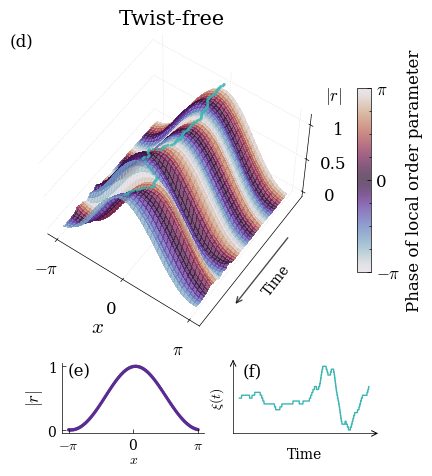

In [10]:
with plt.style.context(['science', 'no-latex']):
    fig = plt.figure(figsize=(6, 5.2))
    gs = GridSpec(
        2, 1,
        height_ratios=[4.2, 1],
        hspace=0.2,
        wspace=0.1,
        figure=fig
    )

    top_gs = gs[0].subgridspec(1, 3, width_ratios=[1, 6, 1], wspace=0.2)
    top_gs = gs[0].subgridspec(1, 3, width_ratios=[0.5, 3.2, 0.12], wspace=0.1)

    ax = fig.add_subplot(top_gs[0, 1], projection='3d')

    T = 4000
    t = np.linspace(0, 10, T)
    R = R_local_1[-T:, :]
    label_position = [0, 2999, 4999]

    T, N = R.shape

    x = np.arange(N)
    t = np.arange(T)

    time_scale = 0.01
    t_plot = t * time_scale

    amp = np.abs(R)
    R_amg = np.abs(R)
    row_min = R_amg.min(axis=1, keepdims=True)
    row_max = R_amg.max(axis=1, keepdims=True)

    denom = row_max - row_min
    amp = (R_amg - row_min) / denom
    phase = np.angle(R)
    phase_norm = (phase + np.pi) / (2 * np.pi)

    cmap = cm.twilight
    colors = cmap(phase_norm)

    X_pos, Y_time = np.meshgrid(x, t_plot, indexing='xy')
    Z_amp = amp[:, ::-1]

    surf = ax.plot_surface(
        X_pos, Y_time, Z_amp,
        facecolors=colors,
        linewidth=0,
        antialiased=False,
        shade=False,
        alpha=0.7
    )

    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.tick_params(axis='z', labelsize=10)

    norm = Normalize(vmin=-np.pi, vmax=np.pi)
    mappable = cm.ScalarMappable(cmap=cmap, norm=norm)
    mappable.set_array([])
    bottom_right_gs = top_gs[0, 2].subgridspec(3, 1, height_ratios=[1, 4, 1], hspace=0.1)
    cax_3d = fig.add_subplot(bottom_right_gs[1, 0])

    cbar = fig.colorbar(mappable, cax=cax_3d, shrink=0.8, pad=0.1)
    cbar.set_ticks([-np.pi, 0, np.pi])
    cbar.set_ticklabels([r'$-\pi$', '0', r'$\pi$'], fontsize=12)

    cbar.solids.set_alpha(0.7)
    cbar.set_label('Phase of local order parameter', fontsize=12)
    pos = cax_3d.get_position()
    cax_3d.set_position([pos.x0 - 0.02, pos.y0, pos.width, pos.height])

    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    white_rgba = (1.0, 1.0, 1.0, 1.0)
    ax.xaxis.set_pane_color(white_rgba)
    ax.yaxis.set_pane_color(white_rgba)
    ax.zaxis.set_pane_color(white_rgba)

    ax.xaxis._axinfo['grid']['color'] = (0.85, 0.85, 0.85, 1)
    ax.yaxis._axinfo['grid']['color'] = (0.85, 0.85, 0.85, 1)
    ax.zaxis._axinfo['grid']['color'] = (0.85, 0.85, 0.85, 1)

    imax = Z_amp.argmax(axis=1)

    x_max = x[imax]
    y_max = Z_amp[np.arange(T), imax]
    z_max = t_plot

    ax.plot(
        x_max,
        z_max,
        y_max + 0.02,
        'w-', linewidth=2, label='max |R| trajectory'
    )

    phase_at_max = phase[np.arange(T), imax]
    phase_at_max_norm = (phase_at_max + np.pi) / (2 * np.pi)
    colors_max = cmap(phase_at_max_norm)

    ax.scatter(
        x_max[::50],
        z_max[::50],
        y_max[::50] + 0.07,
        c='#3AB5B3',
        s=5,
        edgecolors='none',
        linewidths=0.4,
        alpha=0.8
    )

    ax.view_init(elev=55, azim=125)
    ax.set_xticks(ticks=np.array([127, 63, 0]), labels=[r'$-\pi$', '0', r'$\pi$'], rotation=0, fontsize=12)

    ax.set_yticks([])
    ax.annotate(
        '',
        xy=(0.71, 0.07),
        xytext=(0.90, 0.31),
        xycoords='axes fraction',
        arrowprops=dict(arrowstyle='->', lw=1, color='k', alpha=0.7),
        annotation_clip=False
    )
    ax.text2D(
        0.8, 0.16, 'Time',
        transform=ax.transAxes,
        rotation=52,
        va='center',
        ha='left'
    )

    ax.set_zticks(ticks=np.array([0, 0.5, 1]), labels=['0', '0.5', '1'], rotation=0, fontsize=12)
    ax.text2D(
        1.05, 0.75, r'$|r|$',
        transform=ax.transAxes,
        va='bottom', ha='center',
        fontsize=12
    )
    ax.set_xlabel(r'$x$', labelpad=5, fontsize=15)

    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis._axinfo["grid"]['linewidth'] = 0.5
        axis._axinfo["grid"]['linestyle'] = ':'

    ax.tick_params(axis='both', labelsize=12)
    ax.text2D(0.03, 1, '(d)', transform=ax.transAxes, ha='right', va='top', fontsize=12)
    ax.set_title('Twist-free', fontsize=15)

    top_gs = gs[1].subgridspec(1, 3, width_ratios=[3.5, 8, 0], wspace=0.05)
    sub_gs = top_gs[0, 1].subgridspec(1, 2, wspace=0.2)
    ax_inset = fig.add_subplot(sub_gs[0, 0])
    ax_inset.scatter(x, amp[1620, :], c=cmap(phase_norm[1620, :]), s=2)

    for spine in ax_inset.spines.values():
        spine.set_visible(False)

    ax_inset.set_xticks(ticks=np.array([0, 63, 127]), labels=[r'$-\pi$', '0', r'$\pi$'], rotation=0, fontsize=10)
    ax_inset.minorticks_off()
    ax_inset.spines['left'].set_visible(True)
    ax_inset.spines['bottom'].set_visible(True)
    ax_inset.xaxis.set_ticks_position('bottom')
    ax_inset.yaxis.set_ticks_position('left')
    ax_inset.tick_params(axis='both', which='both', top=False, right=False)
    ax_inset.set_xlabel(r'$x$', labelpad=0, fontsize=10)
    ax_inset.set_ylabel(r'$|r|$', labelpad=2, fontsize=12, rotation=90)
    ax_inset.text(0.2, 1.0, '(e)', transform=ax_inset.transAxes, ha='right', va='top', fontsize=12)

    ax_inset = fig.add_subplot(sub_gs[0, 1])
    x = np.linspace(-np.pi, np.pi, N, endpoint=False)
    ax_inset.plot(np.arange(len(imax)), x[imax], c='#3AB5B3')

    for spine in ax_inset.spines.values():
        spine.set_visible(False)

    ax_inset.minorticks_off()
    ax_inset.spines['left'].set_visible(True)
    ax_inset.spines['bottom'].set_visible(True)
    ax_inset.xaxis.set_ticks_position('bottom')
    ax_inset.yaxis.set_ticks_position('left')
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    ax_inset.tick_params(axis='both', which='both', top=False, right=False)
    ax_inset.set_xlabel('Time', labelpad=10, fontsize=10)
    ax_inset.set_ylabel(r'$\xi(t)$', labelpad=5, fontsize=10, rotation=90)
    xlim = ax_inset.get_xlim()
    ylim = ax_inset.get_ylim()

    ax_inset.annotate(
        '',
        xy=(1.04, -0.004), xytext=(0.98, -0.004),
        xycoords=('axes fraction', 'axes fraction'),
        textcoords=('axes fraction', 'axes fraction'),
        arrowprops=dict(arrowstyle='->', lw=0.7, color='k'),
        annotation_clip=False
    )

    ax_inset.annotate(
        '',
        xy=(0.001, 1.05), xytext=(0.001, 0.99),
        xycoords=('axes fraction', 'axes fraction'),
        textcoords=('axes fraction', 'axes fraction'),
        arrowprops=dict(arrowstyle='->', lw=0.7, color='k'),
        annotation_clip=False
    )
    ax_inset.text(0.2, 1.0, '(f)', transform=ax_inset.transAxes, ha='right', va='top', fontsize=12)

plt.show()

In [ ]:
R_local = loadmat('./data/phase_twist.mat')['R_local']

/home/qinjiajie/anaconda3/lib/python3.11/site-packages/matplotlib/ticker.py:2920: RuntimeWarning: invalid value encountered in log10
  majorstep_no_exponent = 10 ** (np.log10(majorstep) % 1)


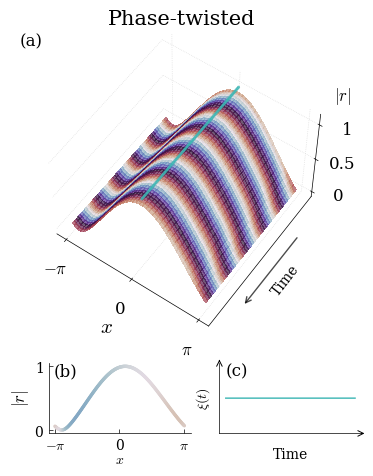

In [11]:
with plt.style.context(['science', 'no-latex']):
    fig = plt.figure(figsize=(6, 5.2))
    gs = GridSpec(
        2, 1,
        height_ratios=[4.2, 1],
        hspace=0.2,
        wspace=0.1,
        figure=fig
    )

    top_gs = gs[0].subgridspec(1, 3, width_ratios=[0.5, 4.2, 0.12], wspace=0.1)

    ax = fig.add_subplot(top_gs[0, 1], projection='3d')

    T = 4000
    t = np.linspace(0, 10, T)
    R = R_local[-T:, :]
    label_position = [0, 2999, 4999]

    T, N = R.shape

    x = np.arange(N)
    t = np.arange(T)

    time_scale = 0.01
    t_plot = t * time_scale

    amp = np.abs(R)
    R_amg = np.abs(R)
    row_min = R_amg.min(axis=1, keepdims=True)
    row_max = R_amg.max(axis=1, keepdims=True)

    denom = row_max - row_min
    amp = (R_amg - row_min) / denom
    phase = np.angle(R)
    phase_norm = (phase + np.pi) / (2 * np.pi)

    cmap = cm.twilight
    colors = cmap(phase_norm)

    X_pos, Y_time = np.meshgrid(x, t_plot, indexing='xy')
    Z_amp = amp[:, ::-1]

    surf = ax.plot_surface(
        X_pos, Y_time, Z_amp,
        facecolors=colors,
        linewidth=0,
        antialiased=False,
        shade=False,
        alpha=0.7
    )

    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.tick_params(axis='z', labelsize=10)

    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    white_rgba = (1.0, 1.0, 1.0, 1.0)
    ax.xaxis.set_pane_color(white_rgba)
    ax.yaxis.set_pane_color(white_rgba)
    ax.zaxis.set_pane_color(white_rgba)

    ax.xaxis._axinfo['grid']['color'] = (0.85, 0.85, 0.85, 1)
    ax.yaxis._axinfo['grid']['color'] = (0.85, 0.85, 0.85, 1)
    ax.zaxis._axinfo['grid']['color'] = (0.85, 0.85, 0.85, 1)

    imax = Z_amp.argmax(axis=1)

    x_max = x[imax]
    y_max = Z_amp[np.arange(T), imax]
    z_max = t_plot

    ax.plot(
        x_max,
        z_max,
        y_max + 0.02,
        'w-', linewidth=2, label='max |R| trajectory'
    )

    phase_at_max = phase[np.arange(T), imax]
    phase_at_max_norm = (phase_at_max + np.pi) / (2 * np.pi)
    colors_max = cmap(phase_at_max_norm)

    ax.scatter(
        x_max[::50],
        z_max[::50],
        y_max[::50] + 0.07,
        c='#3AB5B3',
        s=5,
        edgecolors='none',
        linewidths=0.4,
        alpha=0.8
    )

    ax.view_init(elev=55, azim=125)
    ax.set_xticks(ticks=np.array([255, 127, 0]), labels=[r'$-\pi$', '0', r'$\pi$'], rotation=0, fontsize=12)

    ax.set_yticks([])
    ax.annotate(
        '',
        xy=(0.71, 0.07),
        xytext=(0.90, 0.31),
        xycoords='axes fraction',
        arrowprops=dict(arrowstyle='->', lw=1, color='k', alpha=0.7),
        annotation_clip=False
    )
    ax.text2D(
        0.8, 0.16, 'Time',
        transform=ax.transAxes,
        rotation=52,
        va='center',
        ha='left'
    )

    ax.set_zticks(ticks=np.array([0, 0.5, 1]), labels=['0', '0.5', '1'], rotation=0, fontsize=12)
    ax.text2D(
        1.05, 0.75, r'$|r|$',
        transform=ax.transAxes,
        va='bottom', ha='center',
        fontsize=12
    )
    ax.set_xlabel(r'$x$', labelpad=5, fontsize=15)

    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis._axinfo["grid"]['linewidth'] = 0.5
        axis._axinfo["grid"]['linestyle'] = ':'

    ax.tick_params(axis='both', labelsize=12)
    ax.text2D(0.03, 1, '(a)', transform=ax.transAxes, ha='right', va='top', fontsize=12)
    ax.set_title('Phase-twisted', fontsize=15)

    top_gs = gs[1].subgridspec(1, 3, width_ratios=[2.8, 8, 0.7], wspace=0.05)
    sub_gs = top_gs[0, 1].subgridspec(1, 2, wspace=0.2)
    ax_inset = fig.add_subplot(sub_gs[0, 0])
    ax_inset.scatter(x, amp[1750, :], c=cmap(phase_norm[1750, :]), s=2)

    for spine in ax_inset.spines.values():
        spine.set_visible(False)

    ax_inset.set_xticks(ticks=np.array([0, 127, 255]), labels=[r'$-\pi$', '0', r'$\pi$'], rotation=0, fontsize=10)
    ax_inset.minorticks_off()
    ax_inset.spines['left'].set_visible(True)
    ax_inset.spines['bottom'].set_visible(True)
    ax_inset.xaxis.set_ticks_position('bottom')
    ax_inset.yaxis.set_ticks_position('left')
    ax_inset.tick_params(axis='both', which='both', top=False, right=False)
    ax_inset.set_xlabel(r'$x$', labelpad=0, fontsize=10)
    ax_inset.set_ylabel(r'$|r|$', labelpad=2, fontsize=12, rotation=90)
    ax_inset.text(0.2, 1.0, '(b)', transform=ax_inset.transAxes, ha='right', va='top', fontsize=12)

    ax_inset = fig.add_subplot(sub_gs[0, 1])
    x = np.linspace(-np.pi, np.pi, N, endpoint=False)
    ax_inset.plot(np.arange(len(imax)), x[imax], c='#3AB5B3')

    for spine in ax_inset.spines.values():
        spine.set_visible(False)

    ax_inset.minorticks_off()
    ax_inset.spines['left'].set_visible(True)
    ax_inset.spines['bottom'].set_visible(True)
    ax_inset.xaxis.set_ticks_position('bottom')
    ax_inset.yaxis.set_ticks_position('left')
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    ax_inset.tick_params(axis='both', which='both', top=False, right=False)
    ax_inset.set_xlabel('Time', labelpad=10, fontsize=10)
    ax_inset.set_ylabel(r'$\xi(t)$', labelpad=5, fontsize=10, rotation=90)
    xlim = ax_inset.get_xlim()
    ylim = ax_inset.get_ylim()

    ax_inset.annotate(
        '',
        xy=(1.04, -0.004), xytext=(0.98, -0.004),
        xycoords=('axes fraction', 'axes fraction'),
        textcoords=('axes fraction', 'axes fraction'),
        arrowprops=dict(arrowstyle='->', lw=0.7, color='k'),
        annotation_clip=False
    )

    ax_inset.annotate(
        '',
        xy=(0.001, 1.05), xytext=(0.001, 0.99),
        xycoords=('axes fraction', 'axes fraction'),
        textcoords=('axes fraction', 'axes fraction'),
        arrowprops=dict(arrowstyle='->', lw=0.7, color='k'),
        annotation_clip=False
    )
    ax_inset.text(0.2, 1.0, '(c)', transform=ax_inset.transAxes, ha='right', va='top', fontsize=12)

plt.show()